# Imports

In [52]:
%load_ext autoreload
%autoreload 2

import logging
import numpy as np
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [5]:
import helpers.hio as hio
import L09_05_03_multivariate_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [26]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

import filterpy

# Cell 1: Multi-variate Gaussians

- A multivariate Gaussian is a normal distribution on multiple dimensions
    - The dimensions don't need to be necessarily spatial dimensions
    - E.g., position, velocity, acceleration in 3 dimensions
    - E.g., milk production and feed rate at a dairy

- The components of a Gaussian are correlated
  - E.g., height and weight of people are (positively) correlated
  - E.g., outdoor temperature and home heating bills are (negatively) correlated
  - E.g., the weight of my dog and the price of coffee are uncorrelated

- Correlation allows prediction
  - E.g., height and weight are correlated. If you are much taller than me, I can predict that you weigh more than me
  - Noise in the measurements, uncertainty in the knowledge of the system, intrinsic stochasticity make correlations (and predictions) imperfect

- Assuming linear correlation, the covariance between two vars is defined as
  $$cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

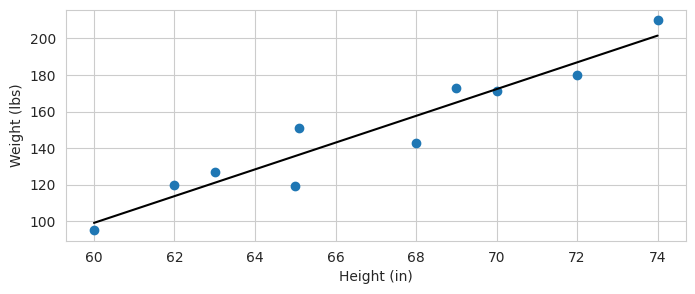

cov=
 [[  20.58322222  150.77888889]
 [ 150.77888889 1213.65555556]]


In [14]:
height = [60, 62, 63, 65, 65.1, 68, 69, 70, 72, 74]
weight = [95, 120, 127, 119, 151, 143, 173, 171, 180, 210]
time_ut.plot_correlated_data(height, weight, xlabel='Height (in)', ylabel='Weight (lbs)', equal=False)
print("cov=\n", np.cov(height, weight))

In [18]:
from filterpy.stats import gaussian, multivariate_gaussian

x = [2.5, 7.3]
mu = [2.0, 7.0]
P = [[8., 0.], 
     [0., 3.]]

multivariate_gaussian(x, mu, P)

0.031507521572225645

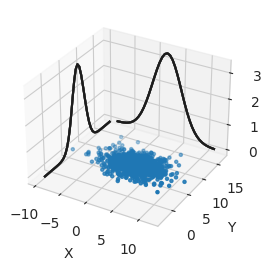

In [19]:
time_ut.plot_3d_sampled_covariance(mu, P)

In [23]:
time_ut.cell_1_1_plot_covariance_matrix()

## Using Correlations to Improve Estimates

- Given an aircraft that we need to locate on a 2D map, ignoring the altitude
- We are tracking an aircraft with two radars
  - Each radar provides the position as two coordinates, such as the "range"
    (distance) and the "bearing" (angle) to a target

- The areas on the X-Y diagrams represent where the plane is likely to be

- One radar measurement (let's assume it's the prior) is equally distributed
  across the two axes (yellow)
- The other radar measurement (let's assume it's the evidence) instead is
  inaccurate along the range but precise along the bearing estimates (green)
- The posterior is given by the multiplication of the two Gaussians (blue)
  - The uncertainty of the posterior is the smaller than the two other measurements

[[1.23099851 1.13263785]
 [1.13263785 1.23099851]]


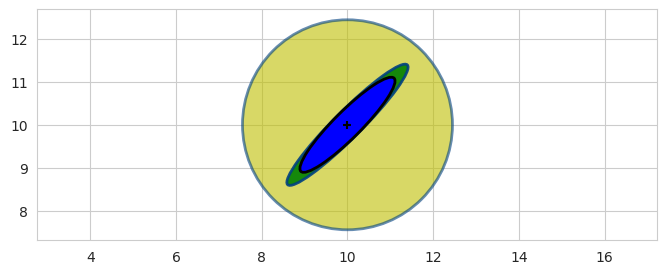

In [32]:
# Prior.
P0 = [[6, 0], [0, 6]]
filterpy.stats.plot_covariance_ellipse((10, 10), P0, fc='y', alpha=0.6)

# Evidence.
P1 = [[2, 1.9], [1.9, 2]]
filterpy.stats.plot_covariance_ellipse((10, 10), P1, fc='g', alpha=0.9)

# Posterior.
P2 = filterpy.stats.multivariate_multiply((10, 10), P0, (10, 10), P1)[1]
print(P2)
filterpy.stats.plot_covariance_ellipse((10, 10), P2, ec='k', fc='b')

- If the two measurements are like below, the resulting measurement is much smaller
  - We are "triangulating" the aircraft
  - This is optimal when the radars are orthogonal

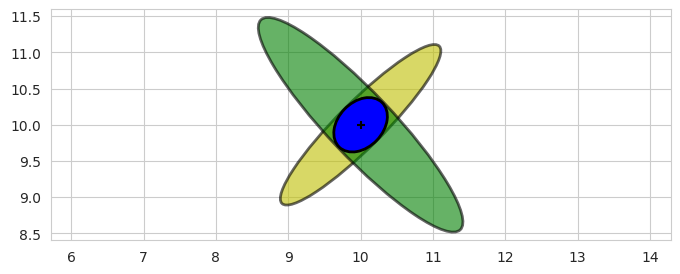

In [34]:
P3 = [[2, -1.9], [-1.9, 2.2]]
filterpy.stats.plot_covariance_ellipse((10, 10), P2, ec='k', fc='y', alpha=0.6)
filterpy.stats.plot_covariance_ellipse((10, 10), P3, ec='k', fc='g', alpha=0.6)

P4 = filterpy.stats.multivariate_multiply((10, 10), P2, (10, 10), P3)[1]
filterpy.stats.plot_covariance_ellipse((10, 10), P4, ec='k', fc='b')

# Cell 1: Sum and Product of Bidimensional Gaussians

## Sum of Two 2D Gaussians

- If $X \sim N(0, \Sigma_1)$ and $Y \sim N(0, \Sigma_2)$ are independent,
  then $X + Y \sim N(0, \Sigma_1 + \Sigma_2)$: the covariances add
    - Yellow: G1
    - Green: G2
    - Blue: G1 + G2
- The sum is always larger (less certain) than either factor

In [43]:
time_ut.cell_1_2_plot_sum_of_gaussians()

## Product of Two 2D Gaussians

- The product of two Gaussian PDFs is also a Gaussian (up to normalization)
- Given $G1 \sim N(0, \Sigma_1)$ and $G2 \sim N(0, \Sigma_2)$:
  $\Sigma^{-1} = \Sigma_1^{-1} + \Sigma_2^{-1}$
    - Yellow: G1
    - Green: G2
    - Blue: G1 * G2
- The product is always smaller (more certain) than either factor

In [44]:
time_ut.cell_1_3_plot_product_of_gaussians()

# Tracking a Dog with Hidden Variables

- We go back to tracking a dog on a 1-d track and use hidden variables to
  improve our estimates
  - The underlying ideas are the same as the previous chapters: we are just
    multiplying and adding Gaussians

- The dog moves approximately 1 meter per step
  - At each step, the velocity varies according to the process variance
    `process_var`
  - After updating the position, a measurement is computed with an assumed
    sensor variance `z_var`
  - Time is discrete

- We start by writing a simulation for the dog
  - The simulation runs for `count` steps

In [50]:
z_var = 1.0
process_var = 0.1
count = 50
xs, zs = time_ut.compute_dog_data(z_var, process_var, count=count)
print("xs=", xs)
print("zs=", zs)

xs= [ 0.65477387  1.87472222  2.78176171  3.30176789  4.58333177  5.74165617
  6.74388974  7.96487869  9.12046871  9.43952189 10.28810019 11.50739747
 12.84257879 14.05874239 15.44199273 16.32521704 16.76352214 17.43800629
 17.95659405 18.75760349 19.58816819 20.23509216 21.18579283 22.23639503
 23.58974756 24.47597873 25.34522957 26.04046223 27.14917751 28.15954883
 29.08668972 30.36819518 30.78437932 31.31113521 32.28474981 32.99323214
 34.05877583 34.83054237 35.65766695 37.18685897 37.77589529 39.03248141
 40.29140164 40.9364218  42.25823461 43.43262673 44.55617562 45.88736656
 46.81482684 47.33064813]
zs= [ 0.26767417  2.72382433  2.71016246  2.94473869  5.15853678  5.79142986
  6.0835686   8.38585163  8.59443386 10.5366746   9.42532442 11.11538483
 13.45958474 12.69278668 15.70324326 16.46860551 17.17217495 16.085336
 19.06928242 20.2913312  17.88081023 21.47090378 20.63750553 22.73817777
 25.03824679 23.14993104 25.60551007 25.08331132 27.10052516 27.40105349
 28.16245658 31.403

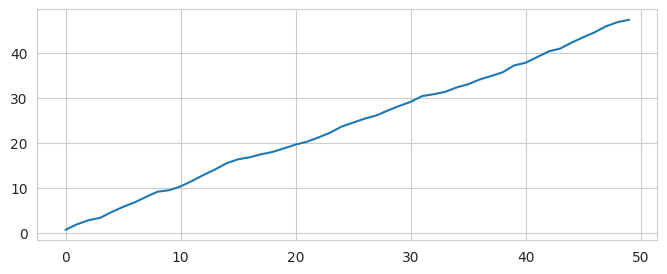

In [54]:
plt.figure(figsize=(8, 3))
plt.plot(xs, label="True position (xs)");

## Predict Step

- The state vector $\mathbf{x}_t$ tracks both position and velocity:
  $$
  \mathbf{x}_t = \begin{bmatrix} x_t \\ \dot{x}_t \end{bmatrix}
  $$
- Position $x_t$ is observed by the sensor
- Velocity $\dot{x}_t$ is a **hidden variable**: it is estimated by the
  filter, not measured directly
- Additional hidden variables (e.g., acceleration, jerk) can be added at
  the cost of a larger state vector

In [61]:
dt = 1.0  # Time step (seconds).
# Initial state: position 0 m, velocity 1 m/s.
x0 = np.array([[0.0], [1.0]])
print("x0 (initial state) =\n", x0)

x0 (initial state) =
 [[0.]
 [1.]]


### Design State Covariance

- The state covariance matrix $P$ encodes our uncertainty about the state
- We initialize it with large diagonal values to reflect ignorance at startup:
  $$
  P = \begin{bmatrix} \sigma_x^2 & 0 \\ 0 & \sigma_{\dot{x}}^2 \end{bmatrix}
    = \begin{bmatrix} 500 & 0 \\ 0 & 49 \end{bmatrix}
  $$
  - $\sigma_x^2 = 500\,\mathrm{m}^2$: we do not know the dog's starting
    position
  - $\sigma_{\dot{x}}^2 = 49\,(\mathrm{m/s})^2$: top dog speed is 21 m/s,
    so $3\,\sigma_{\dot{x}} = 21 \;\Rightarrow\; \sigma_{\dot{x}}^2 = 49$
  - Off-diagonal terms are zero: position and velocity are initially
    uncorrelated

In [ ]:
# Initial state covariance: large uncertainty in position and velocity.
P = np.diag([500.0, 49.0])
print("P =\n", P)

### Design System Model

- The state-transition matrix $F$ describes how the state evolves over one
  time step under a constant-velocity assumption:
  $$
  x_{t+1} = x_t + \dot{x}_t\,\Delta t, \qquad \dot{x}_{t+1} = \dot{x}_t
  $$
- In matrix form $\mathbf{x}_{t+1} = F\,\mathbf{x}_t$:
  $$
  F = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}
  $$
- The constant-velocity assumption is approximate; the filter tolerates
  deviations through the process noise $Q$

In [59]:
# State transition matrix: constant velocity model.
F = np.array([[1.0, dt], [0.0, 1.0]])
print("F =\n", F)

F =
 [[1. 1.]
 [0. 1.]]


### Predicting the System

- Without a new measurement the filter propagates the state and covariance
  forward (the **predict step**):
  $$
  \bar{\mathbf{x}}_t = F\,\mathbf{x}_{t-1}
  $$
  $$
  \bar{P}_t = F\,P_{t-1}\,F^{\top} + Q
  $$
- The covariance $\bar{P}_t$ grows at every prediction step because the
  future velocity is uncertain; adding measurements (update step) shrinks
  it back

In [62]:
# One illustrative prediction step (no measurement yet, Q = 0 for clarity).
x_pred = F @ x0
P_pred = F @ P @ F.T
print("x_pred (one step) =\n", x_pred)
print("P_pred (one step) =\n", P_pred)

x_pred (one step) =
 [[1.]
 [1.]]
P_pred (one step) =
 [[549.  49.]
 [ 49.  49.]]


### Design System Noise

- The dog's velocity is not perfectly constant; it is perturbed by
  unmodeled forces (distraction, fatigue, wind)
- We model the velocity perturbation as zero-mean Gaussian noise $w$:
  $$
  \dot{x}_t = \dot{x}_{t-1} + w, \quad w \sim \mathcal{N}(0,\,q)
  $$
- The process noise covariance $Q = E\!\left[\mathbf{w}\,\mathbf{w}^T\right]$
  captures this uncertainty
- Position is not directly noisy (it inherits noise only through velocity),
  so only the velocity variance is non-zero:
  $$
  Q = \begin{bmatrix} 0 & 0 \\ 0 & q \end{bmatrix}
  $$

In [63]:
# Process noise covariance: only velocity is directly perturbed.
Q = np.array([[0.0, 0.0], [0.0, process_var]])
print("Q =\n", Q)

Q =
 [[0.  0. ]
 [0.  0.1]]


### Design the Control Function

- A known control input $\mathbf{u}$ can shift the predicted state:
  $$
  \bar{\mathbf{x}}_t = F\,\mathbf{x}_{t-1} + B\,\mathbf{u}_t
  $$
- Examples of control inputs:
  - Car: steering angle, throttle
  - Dog: the owner's voice command, the sight of a squirrel
- In this example there is no known control input, so $B = 0$

In [64]:
# No control input in this example.
B = np.zeros((2, 1))
u = np.zeros((1, 1))
print("B =\n", B)
print("u =\n", u)

B =
 [[0.]
 [0.]]
u =
 [[0.]]


## Update Step

### Design the Measurement Function
- The sensor measures only position, not velocity
- The measurement $z_t$ is related to the full state $\mathbf{x}_t$ via the
  measurement matrix $H$:
  $$
  z_t = H\,\mathbf{x}_t + v, \quad v \sim \mathcal{N}(0,\,R)
  $$
- For position-only observation:
  $$
  H = \begin{bmatrix} 1 & 0 \end{bmatrix}
  $$
- The innovation (residual) is the difference between the actual measurement
  and the predicted measurement:
  $$
  \mathbf{y}_t = z_t - H\,\bar{\mathbf{x}}_t
  $$


In [ ]:
# Measurement matrix: H selects position from the state vector.
H = np.array([[1.0, 0.0]])
print("H =", H)

### Design the Measurement Noise Matrix R
- $R$ encodes the variance of the sensor noise:
  $$
  R = \begin{bmatrix} \sigma_z^2 \end{bmatrix}
  $$
- $R$ can be difficult to estimate in practice:
  - Noise may not be Gaussian
  - There can be a systematic bias in the sensor
  - The error can be asymmetric (e.g., a temperature sensor is less precise
    at high temperatures)

In [65]:
# Measurement noise covariance.
R = np.array([[z_var]])
print("R =", R)

R = [[1.]]


## Running the Kalman Filter

- The filter alternates predict and update at every time step
- After a few steps the estimate converges close to the true position
- The uncertainty (shaded band) shrinks rapidly as measurements accumulate

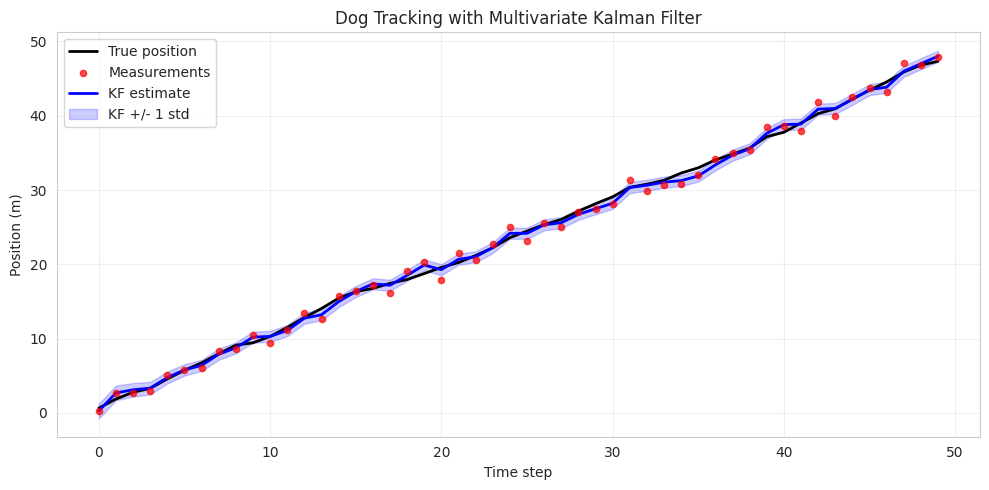

In [57]:
means, variances = time_ut.run_dog_kalman_filter(zs, z_var, process_var)
time_ut.plot_dog_tracking(xs, zs, means, variances)

## Interactive: Dog Tracking with Different Noise Levels

- Increase `z_var` to simulate a noisier sensor: the KF smooths more
  aggressively and leans on its own prediction
- Increase `process_var` to simulate a more erratic dog: the KF trusts
  measurements more and follows them closely
- The blue band shows the $\pm 1\,\sigma$ position uncertainty of the KF

In [69]:
time_ut.cell_dog_tracking_interactive()

# Show Effect of Hidden Variables

## What Changes When We Add a Hidden Variable?

- A **1D Kalman filter** tracks position only: $\mathbf{x}_t = [x_t]$
  - The filter has no model of velocity; it assumes the dog is stationary
    between measurements
  - Each prediction step simply holds position constant: $\bar{x}_t = x_{t-1}$
  - The filter can only react to measurements, not anticipate movement

- A **2D Kalman filter** tracks position and velocity: $\mathbf{x}_t =
  [x_t, \dot{x}_t]^T$
  - Velocity $\dot{x}_t$ is the **hidden variable**: never measured directly,
    but inferred from successive position measurements
  - The prediction step uses velocity to anticipate where the dog will be:
    $\bar{x}_t = x_{t-1} + \dot{x}_{t-1}\,\Delta t$
  - The covariance matrix develops off-diagonal terms that capture the
    correlation between position and velocity errors

## Why Hidden Variables Help

- The 1D filter is essentially a recursive average -- it is well-calibrated
  only when the dog is stationary or very slow
- The 2D filter learns the dog's speed implicitly; after a few steps the
  estimated velocity is close to the true velocity and the position predictions
  are much more accurate
- The improvement is quantified by the Mean Squared Error (MSE) shown below:
  the 2D filter consistently achieves a lower MSE than the 1D filter

## Experiment Setup

- Same dog simulation: the dog moves ~1 m/step with Gaussian velocity noise
- Same measurements: position + Gaussian sensor noise $\sigma^2 = z\_var$
- 1D filter: $F = [[1]]$, $Q = [[process\_var]]$, $H = [[1]]$, $R = [[z\_var]]$
- 2D filter: $F = [[1, \Delta t], [0, 1]]$, $Q = diag(0, process\_var)$,
  $H = [[1, 0]]$, $R = [[z\_var]]$

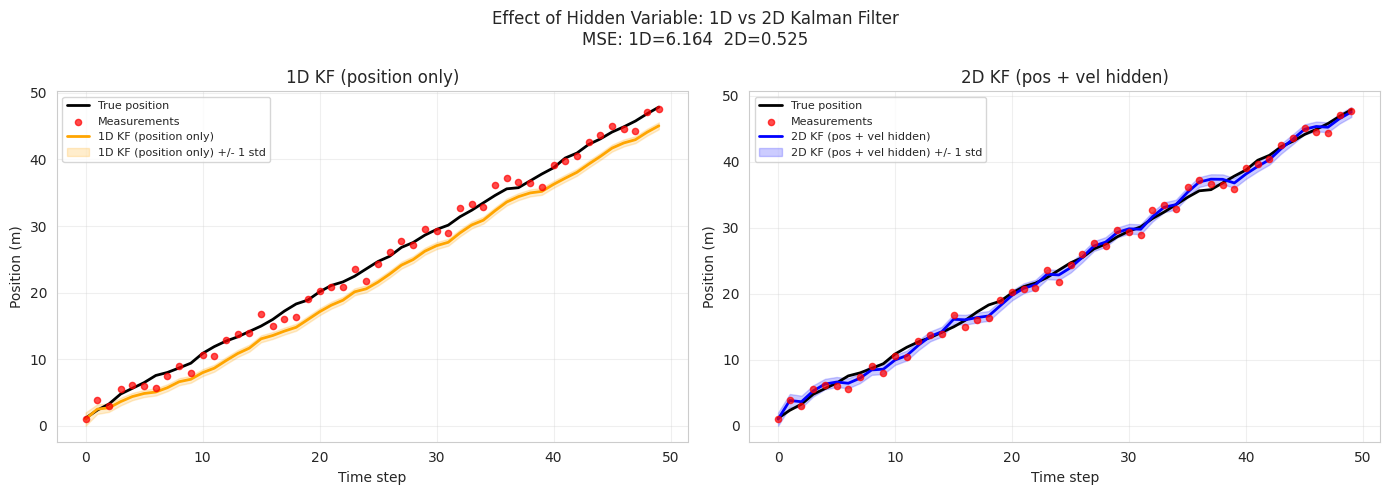

In [70]:
# Static comparison with default parameters.
np.random.seed(42)
xs_ex, zs_ex = time_ut.compute_dog_data(z_var=1.0, process_var=0.1, count=50)
means_1d, var_1d = time_ut.run_dog_kalman_filter_1d(
    zs_ex, z_var=1.0, process_var=0.1
)
means_2d, var_2d = time_ut.run_dog_kalman_filter(
    zs_ex, z_var=1.0, process_var=0.1
)
time_ut.plot_hidden_variable_comparison(
    xs_ex, zs_ex, means_1d, var_1d, means_2d, var_2d
)

## Observations from the Comparison

- **Left panel (1D KF, position only)**:
  - The filter lags behind the true trajectory because each prediction step
    does not use velocity -- it simply holds the previous position estimate
  - The uncertainty band (shaded area) is wide because the filter must account
    for large unpredicted jumps in position
  - MSE is typically higher

- **Right panel (2D KF, position + hidden velocity)**:
  - The filter rapidly learns the dog's velocity from the first few measurements
  - Subsequent predictions are accurate because the motion model
    ($x_{t+1} = x_t + v_t$) anticipates where the dog will be
  - The uncertainty band is narrower and centered on the true trajectory
  - MSE is consistently lower

## Interactive: Vary Noise Levels and See the MSE Difference

- Increase `z_var`: both filters degrade, but 2D degrades less because it
  uses its motion model to bridge noisy measurements
- Increase `process_var`: the dog's velocity changes more erratically; the
  advantage of the 2D filter is reduced but still present

In [71]:
# Interactive comparison of 1D vs 2D Kalman filter.
time_ut.cell_hidden_variable_comparison_interactive()